Train scVI on Muris dataset and test the simulation quality of both sampling from posterior and prior.

In [2]:
import pyrootutils
root = pyrootutils.setup_root(
    search_from=".",
    indicator=".git",
    pythonpath=True,
    dotenv=True,
)

In [3]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from scdeepsim.plot import compare_umap
from scdeepsim.quality import knn_discriminability, rf_discriminability
import scvi

In [4]:
muris = sc.read_h5ad(str(root / 'data' / 'tabula_muris' / 'all.h5ad'))
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=2000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']]
muris_10k = muris_10k.copy()
muris_10k.X = muris_10k.X.toarray() # convert to dense matrix 
muris_10k.X
muris_10k.obs

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: Trying to modify attribute `._uns` of view, initializing view as actual.


,celltype,n_genes,counts
CAGTAACTCATGTCCC-1,Kidney,1578,3106.0
96802,Trachea,1763,6310.0
633053,Trachea,1048,2984.0
AAAGTAGAGGGAGTAA-1,Spleen,1389,4521.0
TGAGGGATCCAAGTAC-1,Marrow,1012,4546.0
...,...,...,...
198663,Trachea,3445,20009.0
TGACAACAGGTTACCT-1,Spleen,781,1801.0
CAAGTTGCAATTCCTT-1,Limb_Muscle,1008,1971.0
AGGCCGTGTATATGGA-1,Spleen,1003,2633.0


In [5]:
# from scdesigner.simulators import NegBinCopula

# nbc = NegBinCopula(mean_formula = "~ celltype")
# nbc.fit(muris_10k, max_epochs=300, top_k=100)
# nbc_samples = nbc.sample(obs=muris_10k.obs)

In [6]:
muris_10k.layers

Layers with keys: 

In [7]:
processed_muris_10k = muris_10k.copy()
sc.pp.normalize_total(processed_muris_10k)
sc.pp.log1p(processed_muris_10k)

In [8]:
muris_10k.obs

,celltype,n_genes,counts
CAGTAACTCATGTCCC-1,Kidney,1578,3106.0
96802,Trachea,1763,6310.0
633053,Trachea,1048,2984.0
AAAGTAGAGGGAGTAA-1,Spleen,1389,4521.0
TGAGGGATCCAAGTAC-1,Marrow,1012,4546.0
...,...,...,...
198663,Trachea,3445,20009.0
TGACAACAGGTTACCT-1,Spleen,781,1801.0
CAAGTTGCAATTCCTT-1,Limb_Muscle,1008,1971.0
AGGCCGTGTATATGGA-1,Spleen,1003,2633.0


In [9]:
import scvi

muris_1k = muris_10k[np.random.choice(muris_10k.n_obs, 1000, replace=False)]
muris_1k  = muris_1k.copy()
scvi.model.SCVI.setup_anndata(muris_1k, 
                              categorical_covariate_keys=['celltype'])
scvi_model = scvi.model.SCVI(muris_1k, use_observed_lib_size=False)
scvi_model.train()

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scvi/train/_trainrunner.py:86: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:3

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


`SCVI.posterior_predictive_sample`:
1. Sample $\hat{z}$ from $p(z|x)$
2. Sample $\hat{x}$ from $p(x|\hat{z})$

(array([984.,   9.,   3.,   1.,   2.,   0.,   0.,   0.,   0.,   1.]),
 array([   185.70303345,  14534.83789062,  28883.97265625,  43233.109375  ,
         57582.2421875 ,  71931.375     ,  86280.515625  , 100629.6484375 ,
        114978.78125   , 129327.9140625 , 143677.046875  ]),
 <BarContainer object of 10 artists>)

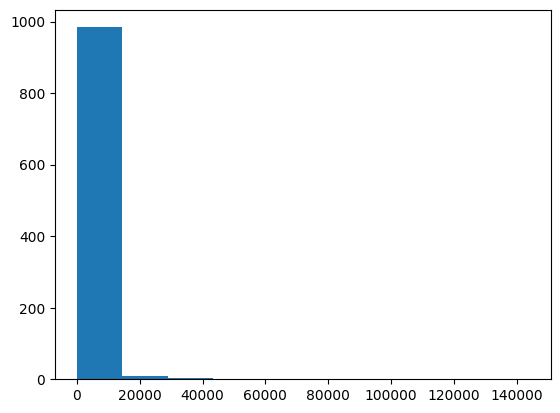

In [10]:
ln = scvi_model.get_latent_library_size()
plt.hist(ln)

In [11]:
scvi_samples = scvi_model.posterior_predictive_sample()

knn_discriminability: (0.7947073676841921, 0.7075)
rf_discriminability: (0.8296082402060051, 0.765)
Performing UMAP on combined dataset (2000 samples, 2000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[0.87741864, 8.242314  ],
         [5.2002354 , 6.249224  ],
         [0.24322708, 8.907423  ],
         ...,
         [2.2946835 , 4.6180997 ],
         [3.3704262 , 8.478722  ],
         [6.11608   , 7.0512104 ]], shape=(1000, 2), dtype=float32),
  array([[-6.444472  ,  1.0915707 ],
         [ 5.6732464 ,  6.133538  ],
         [ 0.45111305,  8.730194  ],
         ...,
         [ 2.3193376 ,  4.70665   ],
         [ 2.4023    ,  7.439482  ],
         [ 6.9785347 ,  5.7239394 ]], shape=(1000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

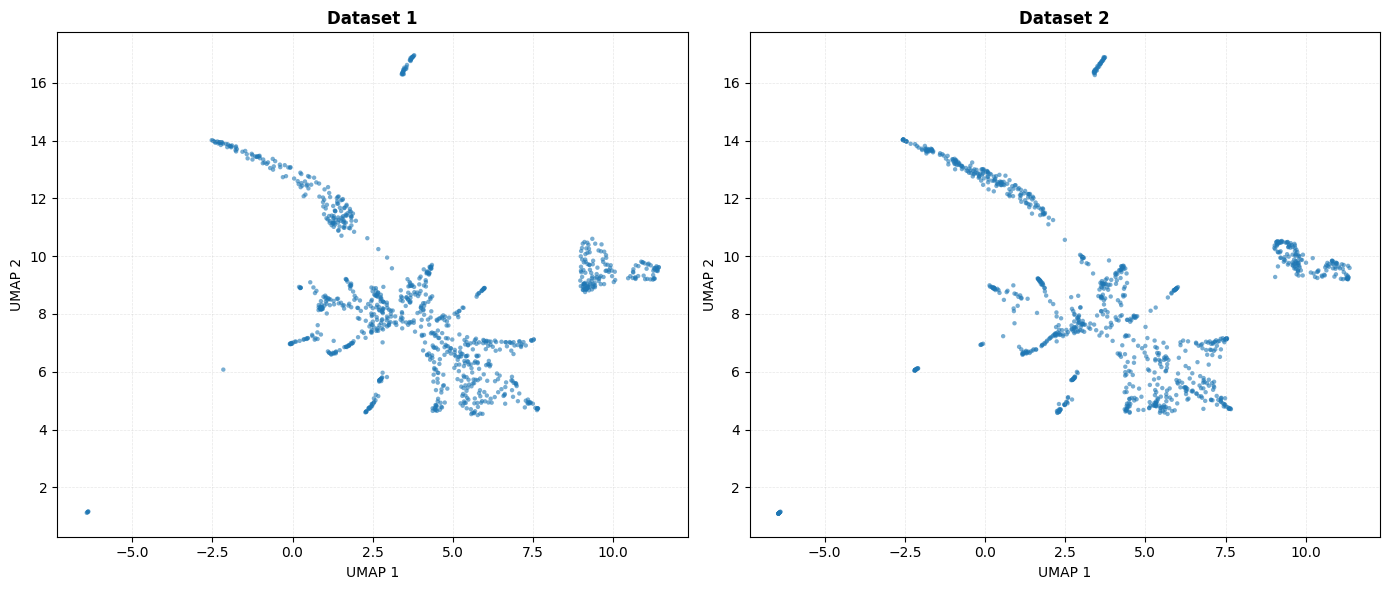

In [ ]:
dense_samples = scvi_samples.todense()
print("knn_discriminability:", knn_discriminability(dense_samples, muris_1k.X))
print("rf_discriminability:", rf_discriminability(dense_samples, muris_1k.X))
compare_umap([dense_samples, muris_1k.X])

Standard VAE sampling:
1. Draw $z \sim \mathcal{N}(0, I)$
2. $x = f_{\text{decoder}}(z)$

In [13]:
scvi_model.summary_stats

n_batch: 1
n_cells: 1000
n_extra_categorical_covs: 1
n_extra_continuous_covs: 0
n_labels: 1
n_vars: 2000

In [14]:
muris_1k.obs

,celltype,n_genes,counts,_scvi_batch,_scvi_labels
CCCATACGTAAGTGGC-1,Marrow,1550,8575.0,0,0
GTAGGCCAGTTGTAGA-1,Lung,1222,2263.0,0,0
TGGTTAGCAAGAAGAG-1,Heart_and_Aorta,3929,14168.0,0,0
AGGGAGTTCTTGGGTA-1,Lung,1073,2481.0,0,0
GAACCTACATTCGACA-1,Lung,937,1779.0,0,0
...,...,...,...,...,...
CACACAAAGTGCAAGC-1,Mammary_Gland,1348,4752.0,0,0
ATAACGCAGCCACCTG-1,Tongue,2392,12086.0,0,0
GACAGAGGTTAGAACA-1,Kidney,1971,5574.0,0,0
GCATACACAATCACAC-1,Limb_Muscle,1418,5753.0,0,0


In [16]:
def sample_from_prior(model, n_samples, data):
    device = model.device
    n_latent = model.get_latent_representation().shape[1]
    z = torch.randn(n_samples, n_latent).to(device)

    obs_indices = np.random.choice(len(data), n_samples, replace=True)
    batch_indices = torch.tensor(
        data.obs['_scvi_batch'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    labels = torch.tensor(
        data.obs['_scvi_labels'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    latent_library = model.get_latent_library_size(indices = obs_indices, give_mean=False)
    library = torch.tensor(np.log(latent_library), dtype=torch.float32).to(device)

    model.module.eval()
    with torch.no_grad():
        scvi_prior_samples = model.module.generative(z = z, 
                                                        batch_index = batch_indices, 
                                                        library = library,
                                                        y = labels)
    px = scvi_prior_samples['px']
    simulated_data = px.sample().cpu().numpy()
    return simulated_data

simulated_data = sample_from_prior(scvi_model, 1000, muris_1k)

In [17]:
print("knn_discriminability:", knn_discriminability(simulated_data, muris_10k.X))
print("rf_discriminability:", rf_discriminability(simulated_data, muris_10k.X))

knn_discriminability: (0.9408236846461715, 0.9590909090909091)
rf_discriminability: (0.9974243117702623, 0.9777272727272728)


Performing UMAP on combined dataset (3000 samples, 2000 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-4.391359 ,  9.638046 ],
         [ 6.5787454, 16.611685 ],
         [ 1.4714944, 15.1655445],
         ...,
         [ 3.281739 , 10.309158 ],
         [ 3.2337635, 13.751229 ],
         [ 7.2597036, 17.497217 ]], shape=(1000, 2), dtype=float32),
  array([[ 1.8776273, 14.899688 ],
         [ 6.234661 , 15.7571335],
         [ 1.3135815, 15.256001 ],
         ...,
         [ 3.2174306, 10.235047 ],
         [ 3.3612869, 15.080221 ],
         [ 5.9200883, 17.245455 ]], shape=(1000, 2), dtype=float32),
  array([[ 7.0997205, 12.061825 ],
         [ 6.250158 , 14.199989 ],
         [ 7.740452 , 12.848416 ],
         ...,
         [ 5.6657815, 13.01911  ],
         [ 4.992451 , 14.433649 ],
         [ 3.318118 , 10.395846 ]], shape=(1000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

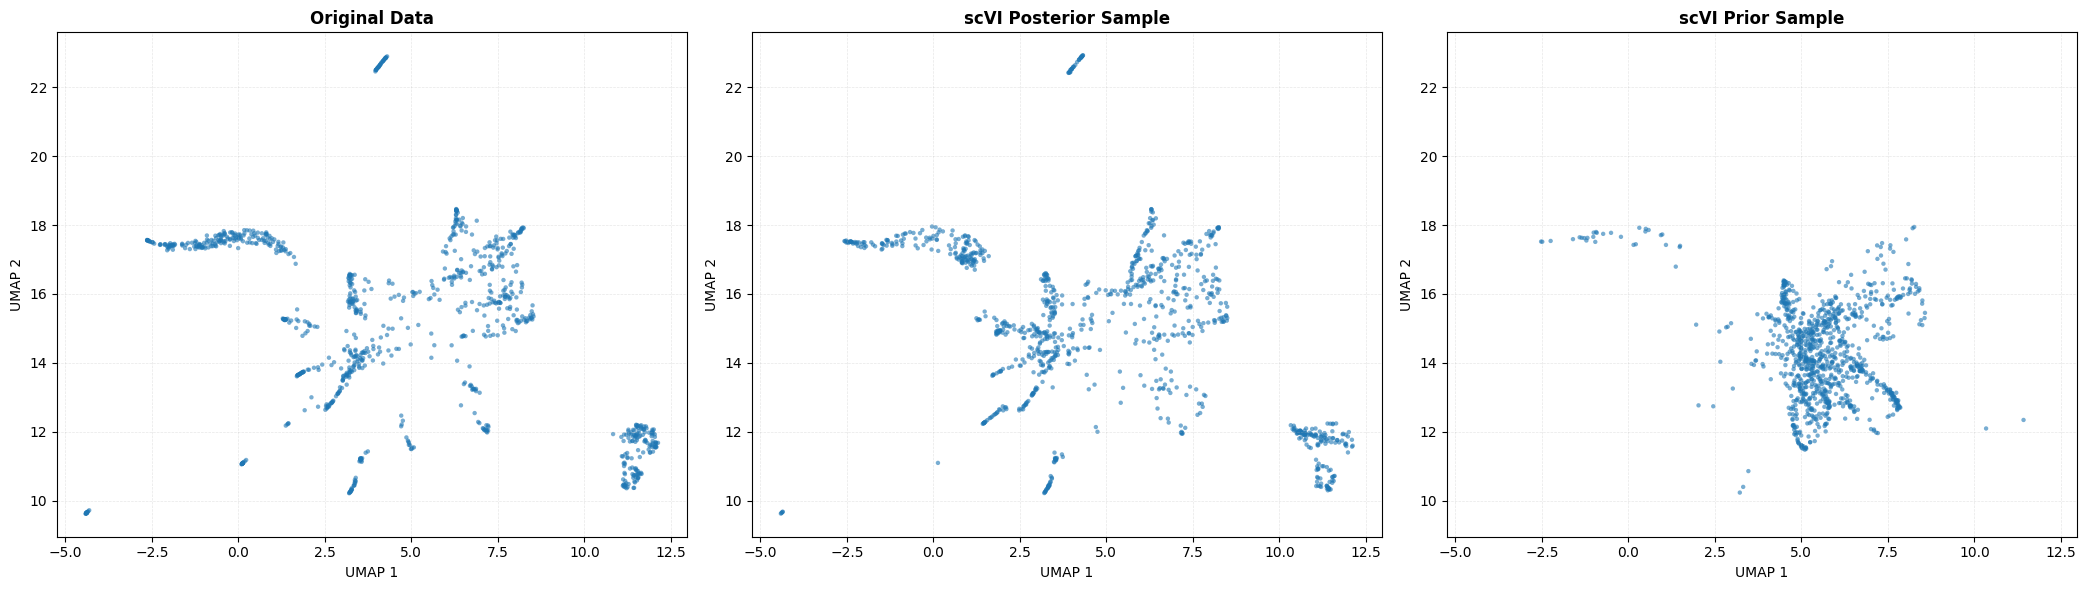

In [26]:
compare_umap([muris_1k.X, dense_samples, simulated_data], title_list=['Original Data', 'scVI Posterior Sample', 'scVI Prior Sample'])

In [19]:
scvi_latent_samples = scvi_model.get_latent_representation()
scvi_latent_samples.shape

(1000, 10)

In [30]:
import anndata as ad
encoded_muris1k = ad.AnnData(X=scvi_latent_samples, obs=muris_1k.obs)
encoded_muris1k

AnnData object with n_obs × n_vars = 1000 × 10
    obs: 'celltype', 'n_genes', 'counts', '_scvi_batch', '_scvi_labels'

In [ ]:
from scdeepsim.lightning_diffusion import LightningDiffusion
import pytorch_lightning as pl
from scdeepsim.dataset import ScDataModule
import os

latent_dm = ScDataModule(
    encoded_muris1k,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

latent_dm.setup()

dim = encoded_muris1k.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999)

trainer = pl.Trainer(
    max_epochs=400,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=str(root / 'experiments' / 'outputs' / 'lightning_logs' / 'muris1k' / 'diffusion'),
)

diffusion_model_path = str(root / 'experiments' / 'outputs' / 'checkpoints' / 'muris1k' / 'trained_diffusion_model.ckpt')
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

In [ ]:
diffusion.eval()

with torch.no_grad():
    diffusion_latent_samples = diffusion.sample(num_samples=1000,
                                    sampling_timesteps=1000,
                                    ddim_sampling_eta=0.1,
                                    use_ema=True,
                                    clip_denoised=False, 
                                    )


In [33]:
knn_discriminability(diffusion_latent_samples, scvi_latent_samples)

(0.8542588564714118, 0.76)

In [34]:
def sample_from_z(model, n_samples, data, z):
    device = model.device
    obs_indices = np.random.choice(len(data), n_samples, replace=True)
    batch_indices = torch.tensor(
        data.obs['_scvi_batch'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    labels = torch.tensor(
        data.obs['_scvi_labels'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    latent_library = model.get_latent_library_size(indices = obs_indices, give_mean=False)
    library = torch.tensor(np.log(latent_library), dtype=torch.float32).to(device)

    model.module.eval()
    with torch.no_grad():
        scvi_prior_samples = model.module.generative(z = z, 
                                                        batch_index = batch_indices, 
                                                        library = library,
                                                        y = labels)
    px = scvi_prior_samples['px']
    simulated_data = px.sample().cpu().numpy()
    return simulated_data

simulated_data = sample_from_z(scvi_model, 1000, muris_1k, diffusion_latent_samples)
knn_discriminability(simulated_data, muris_1k.X)

(0.9118102952573814, 0.8275)

In [37]:
simulated_data = sample_from_z(scvi_model, 1000, muris_1k, torch.tensor(scvi_latent_samples))
knn_discriminability(simulated_data, muris_1k.X)

(0.9405860146503663, 0.8625)